# Testear GPU

In [82]:
import sys

print(sys.executable)

/home/jgaldeano/envs/classifier/bin/python


In [83]:
import os
import tensorflow as tf

print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))
print("VIRTUAL_ENV:", os.environ.get("VIRTUAL_ENV"))
print("GPU:", tf.config.list_physical_devices("GPU"))

LD_LIBRARY_PATH: /home/jgaldeano/envs/classifier/lib/python3.10/site-packages/nvidia/cublas/lib:/home/jgaldeano/envs/classifier/lib/python3.10/site-packages/nvidia/cudnn/lib:/home/jgaldeano/envs/classifier/lib/python3.10/site-packages/nvidia/cuda_runtime/lib:/home/jgaldeano/envs/classifier/lib/python3.10/site-packages/nvidia/cufft/lib:/home/jgaldeano/envs/classifier/lib/python3.10/site-packages/nvidia/curand/lib:/home/jgaldeano/envs/classifier/lib/python3.10/site-packages/nvidia/cusolver/lib:/home/jgaldeano/envs/classifier/lib/python3.10/site-packages/nvidia/cusparse/lib:/home/jgaldeano/envs/classifier/lib/python3.10/site-packages/nvidia/nccl/lib
VIRTUAL_ENV: /home/jgaldeano/envs/classifier
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [84]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "No se ha detectado ninguna GPU. Comprueba la configuración de TensorFlow y CUDA."
    )

print(f"TensorFlow {tf.__version__}")
print(f"GPU detectada: {gpus[0].name}")

TensorFlow 2.21.0
GPU detectada: /physical_device:GPU:0


# Creación de datasets

In [85]:
from pathlib import Path

# Carpeta raíz del proyecto (asumiendo que el notebook está en /tfm/notebooks)
ROOT_DIR = Path.cwd().parent

DATASET_VERSION = "v1"
MODEL_NAME = "classifier_v1"

RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "classifier"
    / f"dataset_{DATASET_VERSION}"
    / MODEL_NAME
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(RESULTS_DIR)

/home/jgaldeano/tfm/results/classifier/dataset_v1/classifier_v1


In [86]:
from pathlib import Path

import matplotlib.pyplot as plt
import tensorflow as tf


# ==========================================================
# PATHS
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "data" / "datasets" / "classifier"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"


# ==========================================================
# CONFIGURACIÓN
# ==========================================================

IMAGE_SIZE = (128,128)
BATCH_SIZE = 9
SEED = 42


# ==========================================================
# DATASETS
# ==========================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ==========================================================
# INFORMACIÓN
# ==========================================================

print(f"Clases: {train_ds.class_names}")
print(f"Número de clases: {len(train_ds.class_names)}")

Found 2370 files belonging to 2 classes.
Found 1022 files belonging to 2 classes.
Clases: ['Green', 'Red']
Número de clases: 2


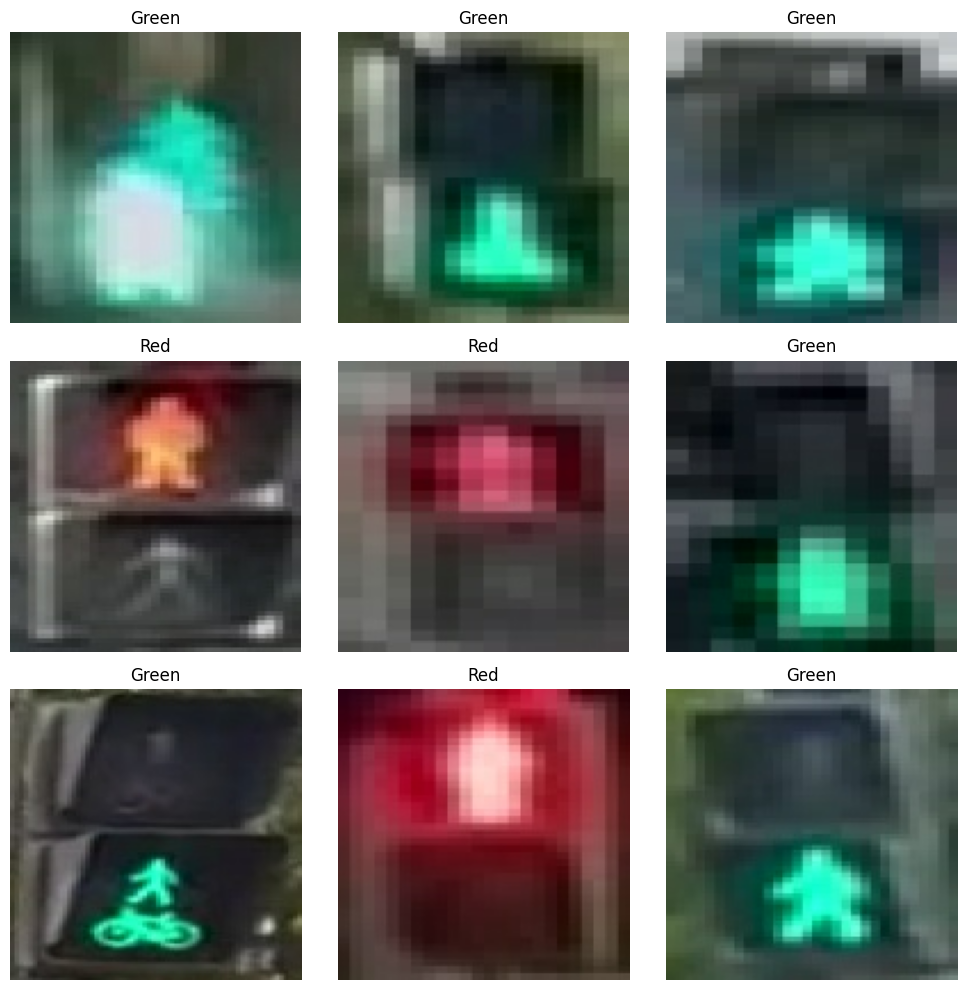

In [87]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i].numpy()])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [88]:
for images, labels in train_ds.take(1):

    print(images.shape)
    print(images.dtype)

    print(labels.shape)
    print(labels.dtype)

    print(images.numpy().min(), images.numpy().max())

(9, 128, 128, 3)
<dtype: 'float32'>
(9,)
<dtype: 'int32'>
0.0 255.0


In [89]:
for index, class_name in enumerate(train_ds.class_names):
    print(f"{index} -> {class_name}")

0 -> Green
1 -> Red


In [90]:
import tensorflow as tf


# =====================================================
# DATA AUGMENTATION
# =====================================================

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        mode="horizontal",
    ),

    tf.keras.layers.RandomRotation(
        factor=0.03,
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
    ),

    tf.keras.layers.RandomZoom(
        height_factor=(-0.15, 0.10),
        width_factor=(-0.15, 0.10),
    ),

    tf.keras.layers.RandomContrast(
        factor=0.20,
    ),

])


# =====================================================
# INPUT
# =====================================================

inputs = tf.keras.Input(shape=(128, 128, 3))

x = data_augmentation(inputs)

x = tf.keras.layers.Rescaling(1 / 255)(x)


# =====================================================
# BLOQUE 1
# =====================================================

x = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding="same",
    use_bias=False,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="conv_1",
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Activation("silu")(x)


x = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding="same",
    use_bias=False,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="conv_2",
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Activation("silu")(x)

x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)


# =====================================================
# BLOQUE 2
# =====================================================

x = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=3,
    padding="same",
    use_bias=False,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="conv_3",
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Activation("silu")(x)


x = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=3,
    padding="same",
    use_bias=False,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="conv_4",
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Activation("silu")(x)

x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)


# =====================================================
# BLOQUE 3
# =====================================================

x = tf.keras.layers.Conv2D(
    filters=128,
    kernel_size=3,
    padding="same",
    use_bias=False,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="conv_5",
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Activation("silu")(x)


x = tf.keras.layers.Conv2D(
    filters=128,
    kernel_size=3,
    padding="same",
    use_bias=False,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="conv_6",
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Activation("silu")(x)

x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)


# =====================================================
# BLOQUE 4
# =====================================================

x = tf.keras.layers.Conv2D(
    filters=256,
    kernel_size=3,
    padding="same",
    use_bias=False,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="conv_7",
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Activation("silu")(x)


x = tf.keras.layers.Conv2D(
    filters=256,
    kernel_size=3,
    padding="same",
    use_bias=False,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="conv_8",
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Activation("silu")(x)


# =====================================================
# CLASIFICADOR
# =====================================================

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.30)(x)

x = tf.keras.layers.Dense(
    units=256,
    activation="silu",
)(x)

x = tf.keras.layers.Dropout(0.20)(x)

x = tf.keras.layers.Dense(
    units=64,
    activation="silu",
)(x)

outputs = tf.keras.layers.Dense(
    units=1,
    activation="sigmoid",
)(x)


# =====================================================
# MODELO
# =====================================================

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
)

model.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_5 (Conv2D)                 │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_6 (Conv2D)                 │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,257,441 (4.80 MB)

 Trainable params: 1,255,521 (4.79 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [91]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4,
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"],
)

In [92]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=RESULTS_DIR / "best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1,
)

In [93]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    verbose=2,
    callbacks=[
        lr_scheduler,
        early_stopping,
        checkpoint,
    ],
)

Epoch 1/50

Epoch 1: val_loss improved from None to 2.83445, saving model to /home/jgaldeano/tfm/results/classifier/dataset_v1/classifier_v1/best.keras
264/264 - 14s - 54ms/step - accuracy: 0.9865 - loss: 0.1327 - val_accuracy: 0.5626 - val_loss: 2.8344 - learning_rate: 3.0000e-04
Epoch 2/50

Epoch 2: val_loss improved from 2.83445 to 0.32561, saving model to /home/jgaldeano/tfm/results/classifier/dataset_v1/classifier_v1/best.keras
264/264 - 12s - 45ms/step - accuracy: 0.9861 - loss: 0.1348 - val_accuracy: 0.9354 - val_loss: 0.3256 - learning_rate: 3.0000e-04
Epoch 3/50

Epoch 3: val_loss improved from 0.32561 to 0.25693, saving model to /home/jgaldeano/tfm/results/classifier/dataset_v1/classifier_v1/best.keras
264/264 - 13s - 48ms/step - accuracy: 0.9932 - loss: 0.0884 - val_accuracy: 0.9432 - val_loss: 0.2569 - learning_rate: 3.0000e-04
Epoch 4/50

Epoch 4: val_loss did not improve from 0.25693
264/264 - 13s - 49ms/step - accuracy: 0.9983 - loss: 0.0702 - val_accuracy: 0.9051 - val_

In [103]:
def plot_history(history: tf.keras.callbacks.History) -> None:
    """Plot training and validation loss/accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='train')
    axes[1].plot(history.history['val_accuracy'], label='val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout()

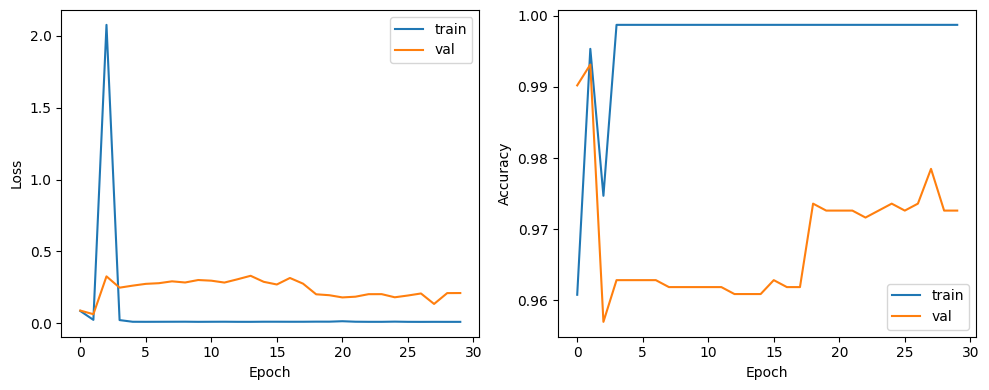

In [104]:
plot_history(hist)

In [105]:
import numpy as np
import matplotlib.pyplot as plt


def show_errors(val_ds, model, class_names_list, n_images=16, cols=4):

    errors = []

    # Buscar ejemplos mal clasificados
    for images, labels in val_ds:

        pred_probs = model.predict(images, verbose=0)

        # Sigmoid -> convertir probabilidad a clase
        preds = (pred_probs >= 0.5).astype(int).reshape(-1)

        labels_np = labels.numpy().astype(int).reshape(-1)

        bad_pred_inds = np.where(preds != labels_np)[0]

        for ind in bad_pred_inds:

            errors.append(
                (
                    images[ind],
                    labels_np[ind],
                    preds[ind],
                    float(pred_probs[ind][0])
                )
            )

            if len(errors) == n_images:
                break

        if len(errors) == n_images:
            break


    if len(errors) == 0:
        print("No se han encontrado errores de clasificación.")
        return


    # Crear grid
    rows = int(np.ceil(len(errors) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows)
    )

    # Ajustar cuando solo hay una fila
    if rows == 1:
        axes = np.array([axes])

    axes = axes.flatten()


    # Pintar errores
    for ax, (image, real_label, pred_label, prob_positive) in zip(axes, errors):

        real_class = class_names_list[real_label]
        pred_class = class_names_list[pred_label]


        # Probabilidad de la clase predicha
        if pred_label == 1:
            prob_pred = prob_positive
        else:
            prob_pred = 1 - prob_positive


        # Probabilidad de la clase real
        if real_label == 1:
            prob_real = prob_positive
        else:
            prob_real = 1 - prob_positive


        # Imagen correctamente escalada para visualizar
        img = image.numpy()

        if img.max() > 1:
            img = img.astype("uint8")


        ax.imshow(img)

        ax.set_title(
            f"Pred: {pred_class} ({prob_pred:.2f})\n"
            f"Real: {real_class} ({prob_real:.2f})",
            fontsize=10
        )

        ax.axis("off")


    # Ocultar espacios vacíos
    for ax in axes[len(errors):]:
        ax.axis("off")


    plt.tight_layout()
    plt.show()

In [106]:
class_names

['Green', 'Red']

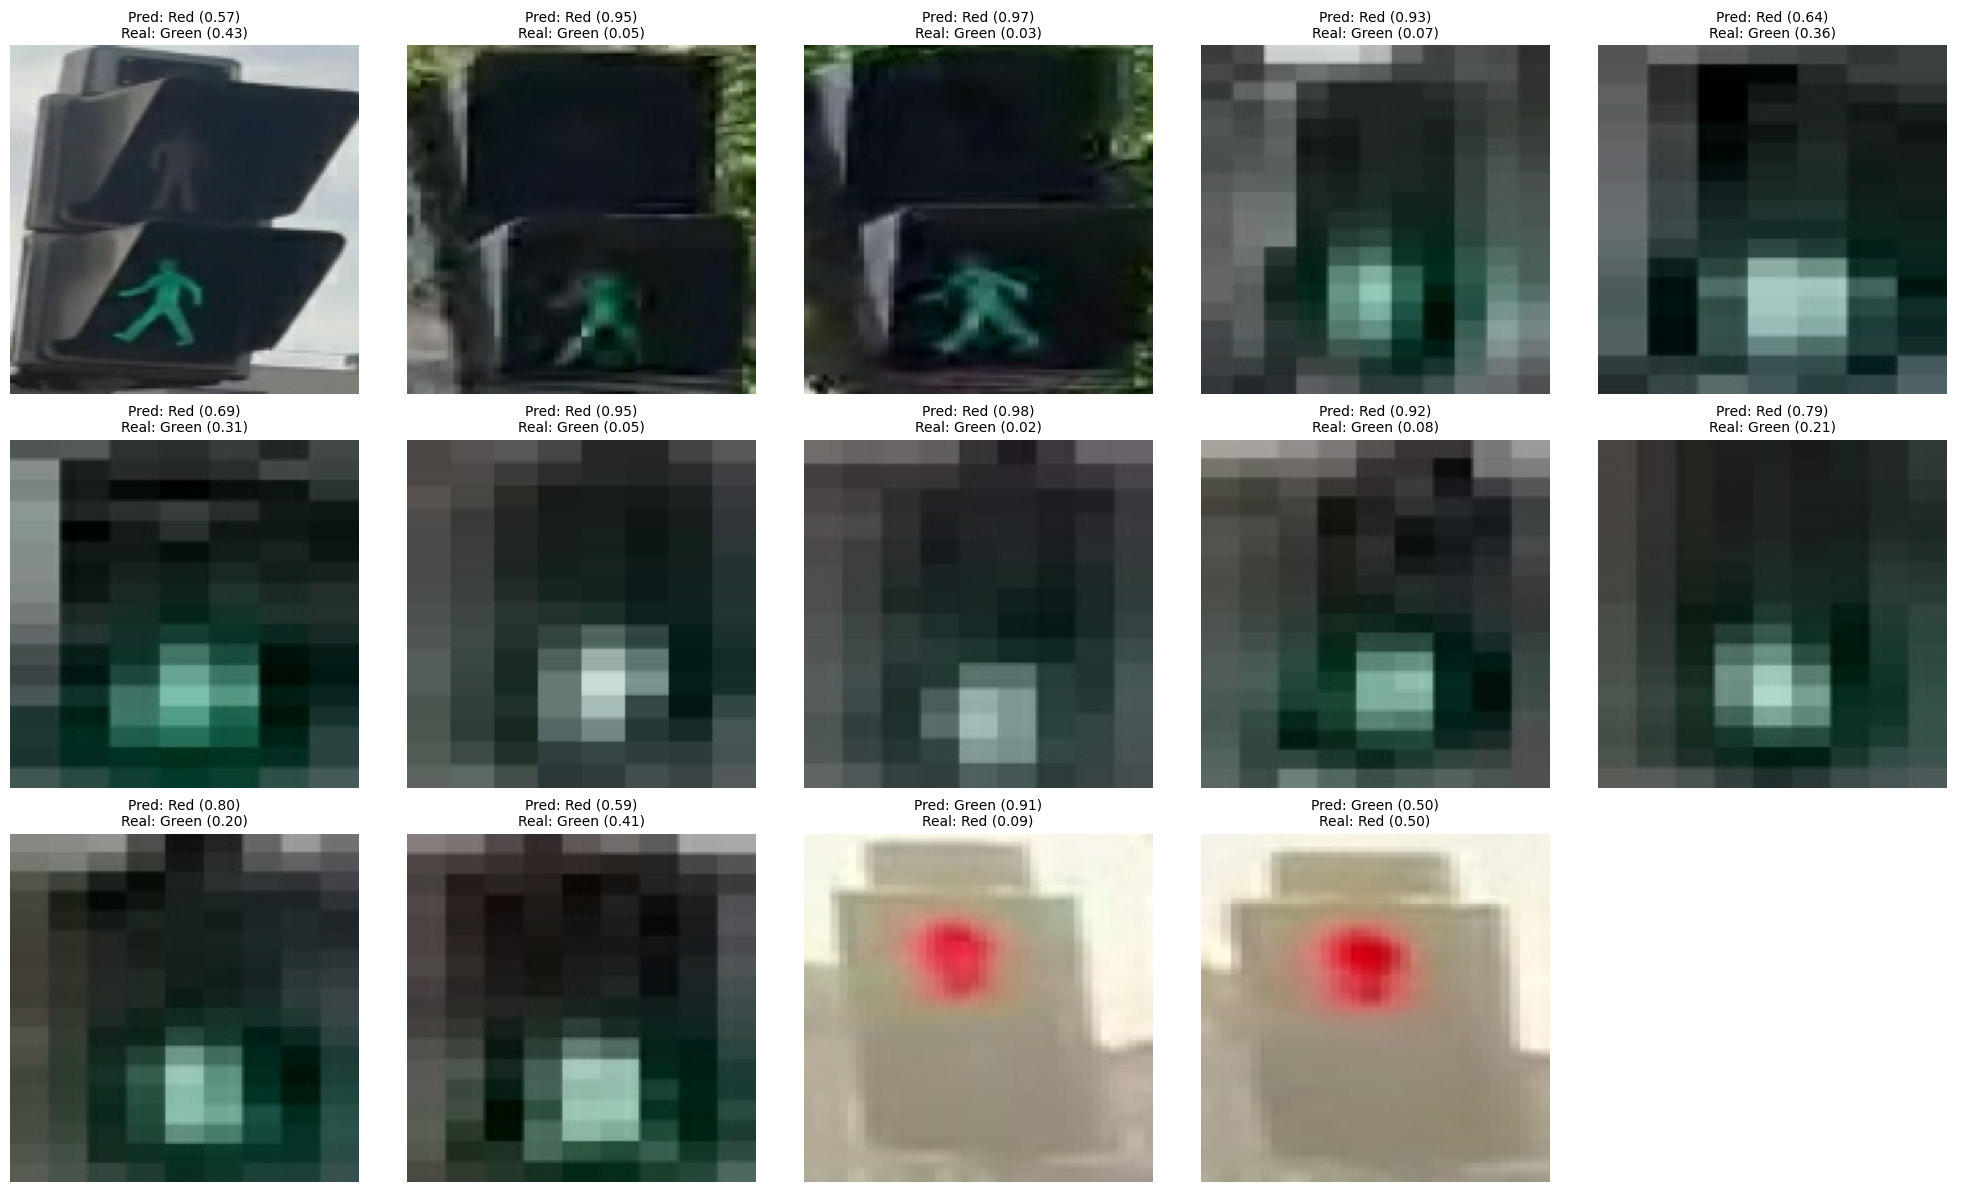

In [107]:
show_errors(
    val_ds,
    model,
    class_names,
    n_images=50,
    cols=5
)

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)


def evaluate_classifier(model, val_ds, class_names):

    y_true = []
    y_pred = []

    # Obtener predicciones
    for images, labels in val_ds:

        probs = model.predict(images, verbose=0)

        # Sigmoid -> clase 0/1
        preds = (probs >= 0.5).astype(int).reshape(-1)

        y_pred.extend(preds)
        y_true.extend(labels.numpy().astype(int).reshape(-1))


    y_true = np.array(y_true)
    y_pred = np.array(y_pred)


    # =========================
    # Accuracy
    # =========================

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    print(f"Accuracy: {accuracy:.4f}")


    # =========================
    # Classification report
    # =========================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=4
        )
    )


    # =========================
    # Confusion Matrix
    # =========================

    cm = confusion_matrix(
        y_true,
        y_pred
    )


    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")

    plt.show()

    return cm, y_true, y_pred

Accuracy: 0.9863

Classification Report:

              precision    recall  f1-score   support

       Green     0.9954    0.9732    0.9842       447
         Red     0.9795    0.9965    0.9879       575

    accuracy                         0.9863      1022
   macro avg     0.9875    0.9848    0.9860      1022
weighted avg     0.9865    0.9863    0.9863      1022



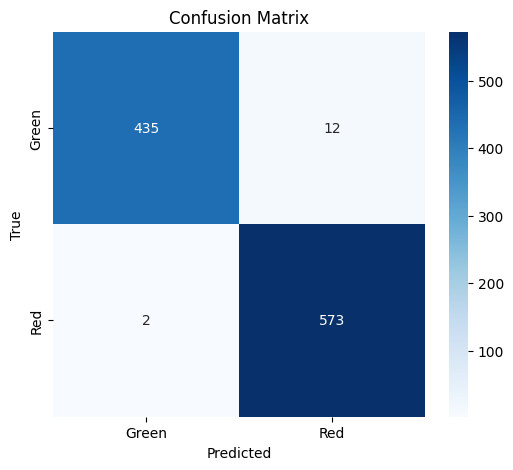

(array([[435,  12],
        [  2, 573]]),
 array([0, 0, 0, ..., 1, 1, 1], shape=(1022,)),
 array([0, 0, 0, ..., 1, 1, 1], shape=(1022,)))

In [109]:
evaluate_classifier(model, val_ds, class_names)

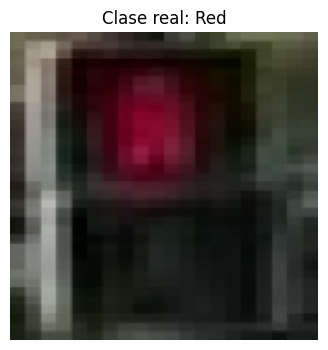

dict_keys(['input_layer_10', 'sequential_3', 'rescaling_7', 'conv_1', 'batch_normalization_24', 'activation_24', 'conv_2', 'batch_normalization_25', 'activation_25', 'max_pooling2d_16', 'conv_3', 'batch_normalization_26', 'activation_26', 'conv_4', 'batch_normalization_27', 'activation_27', 'max_pooling2d_17', 'conv_5', 'batch_normalization_28', 'activation_28', 'conv_6', 'batch_normalization_29', 'activation_29', 'max_pooling2d_18', 'conv_7', 'batch_normalization_30', 'activation_30', 'conv_8', 'batch_normalization_31', 'activation_31', 'global_average_pooling2d_7', 'dropout_6', 'dense_21', 'dropout_7', 'dense_22', 'dense_23'])


In [110]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model



images, labels = next(iter(train_ds))

idx = np.random.randint(0, images.shape[0])

imagen = images[idx]
label = int(labels[idx].numpy())




img_display = imagen.numpy()

# Deshacer normalización para visualizar
if img_display.max() <= 1:
    img_display = img_display * 255

img_display = img_display.astype("uint8")


plt.figure(figsize=(4,4))
plt.imshow(img_display)
plt.title(f"Clase real: {class_names[label]}")
plt.axis("off")
plt.show()




imagen_predecir = tf.expand_dims(imagen, axis=0)


outputs_dict = {
    layer.name: layer.output
    for layer in model.layers
}


feature_extractor = Model(
    inputs=model.inputs,
    outputs=outputs_dict
)


features = feature_extractor(imagen_predecir)


print(features.keys())

(1, 128, 128, 32)


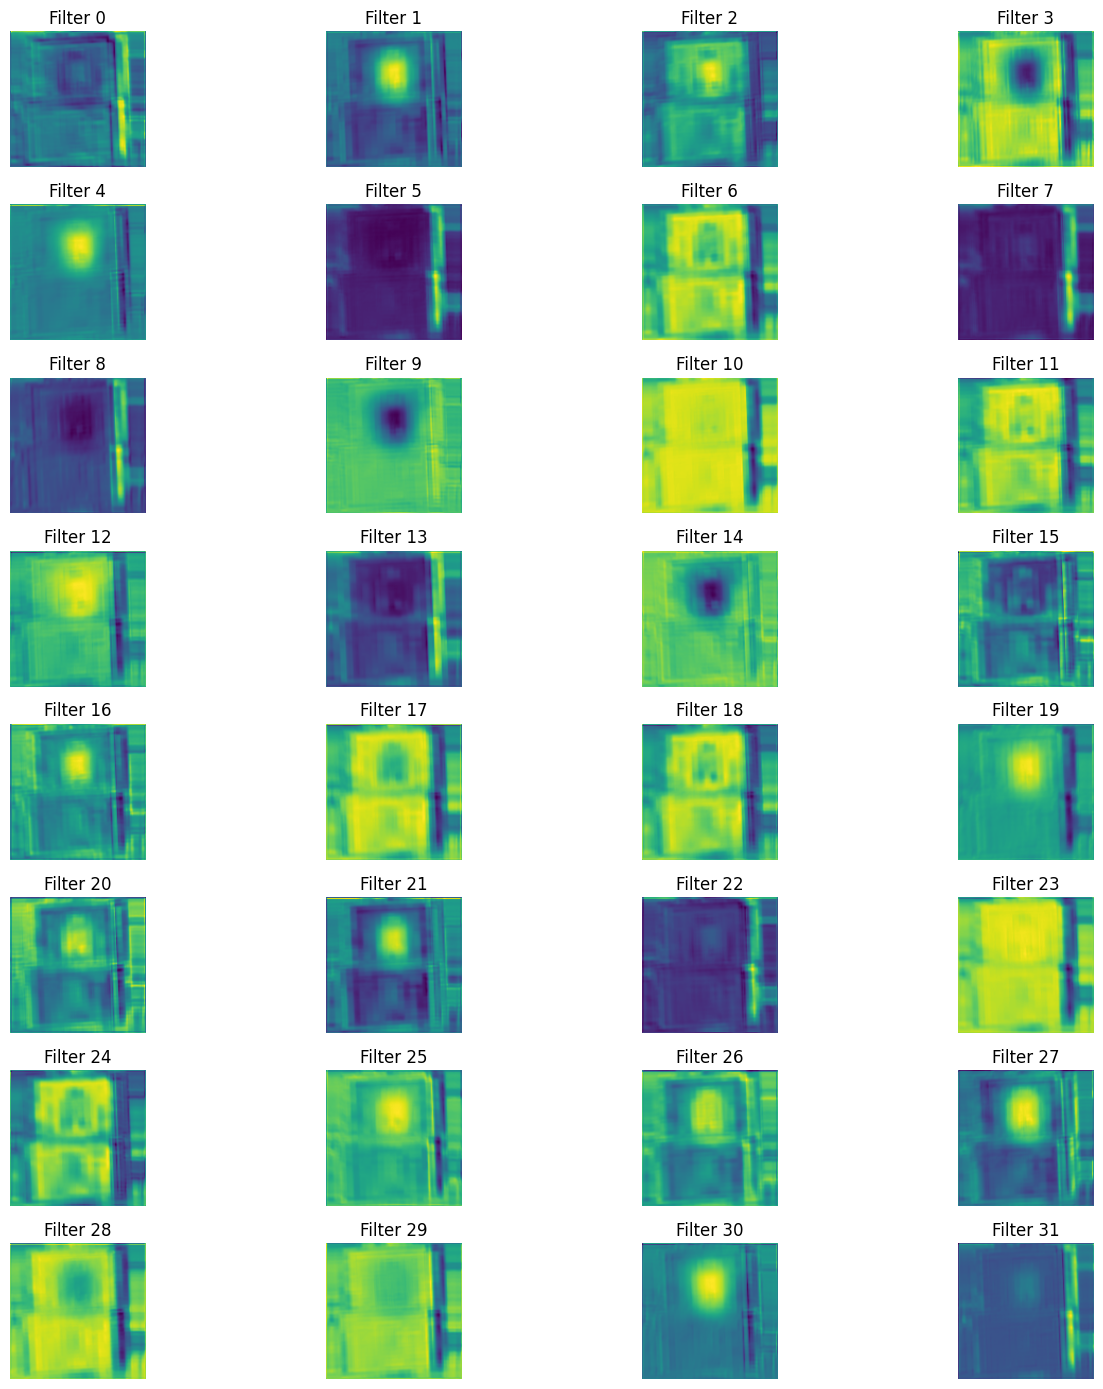

In [111]:


feature_maps = features["conv_2"]   # cambia por la capa que quieras visualizar

print(feature_maps.shape)




n_filters = feature_maps.shape[-1]

plt.figure(figsize=(14,14))

for i in range(min(n_filters, 32)):

    plt.subplot(8, 4, i + 1)

    plt.imshow(
        feature_maps[0, :, :, i],
        cmap="viridis"
    )

    plt.axis("off")
    plt.title(f"Filter {i}")


plt.tight_layout()
plt.show()

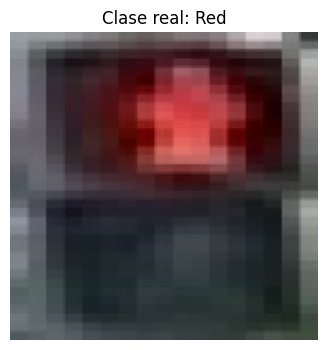

dict_keys(['input_layer_10', 'sequential_3', 'rescaling_7', 'conv_1', 'batch_normalization_24', 'activation_24', 'conv_2', 'batch_normalization_25', 'activation_25', 'max_pooling2d_16', 'conv_3', 'batch_normalization_26', 'activation_26', 'conv_4', 'batch_normalization_27', 'activation_27', 'max_pooling2d_17', 'conv_5', 'batch_normalization_28', 'activation_28', 'conv_6', 'batch_normalization_29', 'activation_29', 'max_pooling2d_18', 'conv_7', 'batch_normalization_30', 'activation_30', 'conv_8', 'batch_normalization_31', 'activation_31', 'global_average_pooling2d_7', 'dropout_6', 'dense_21', 'dropout_7', 'dense_22', 'dense_23'])


In [112]:


for images, labels in train_ds.take(1):

    # seleccionar imagen aleatoria del batch
    idx = np.random.randint(0, images.shape[0])

    imagen = images[idx]
    label = int(labels[idx].numpy())


# añadir dimensión batch
imagen_input = tf.expand_dims(imagen, axis=0)




img = imagen.numpy()

# si está normalizada, recuperar rango visible
if img.max() <= 1:
    img = img * 255

plt.figure(figsize=(4,4))
plt.imshow(img.astype("uint8"))
plt.title(f"Clase real: {class_names[label]}")
plt.axis("off")
plt.show()



outputs_dict = {
    layer.name: layer.output
    for layer in model.layers
}


feature_extractor = Model(
    inputs=model.inputs,
    outputs=outputs_dict
)


features = feature_extractor(imagen_input)


# Mostrar capas disponibles
print(features.keys())

In [113]:
features = feature_extractor(imagen_input)

(1, 64, 64, 64)


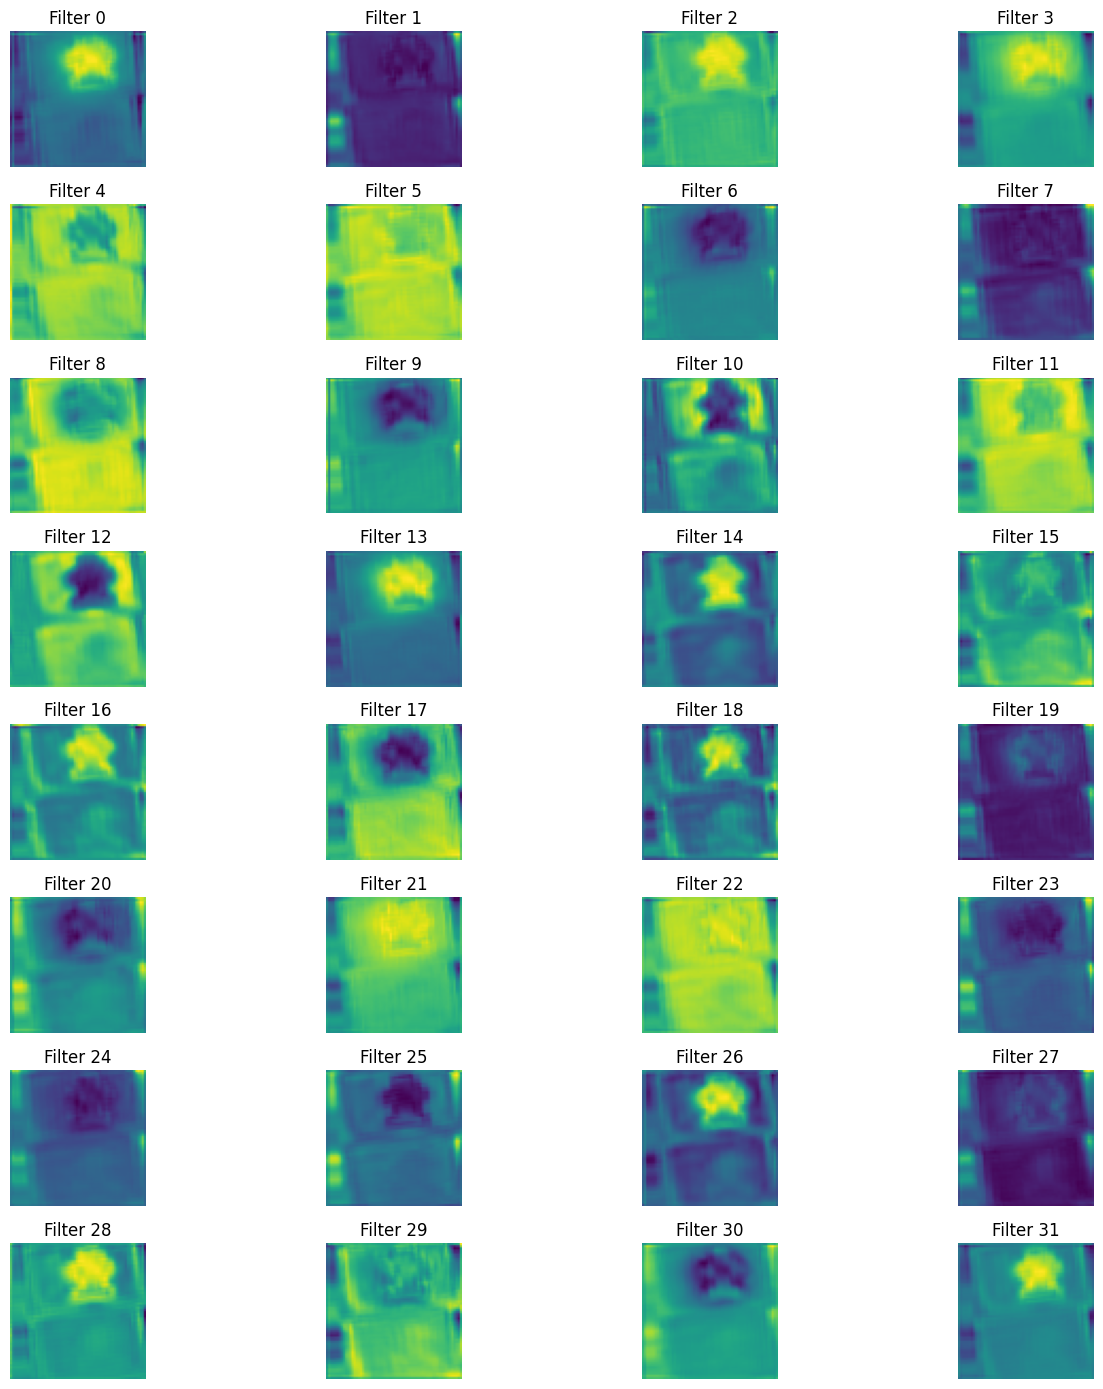

In [117]:


feature_maps = features["conv_3"]   # cambia por la capa que quieras visualizar

print(feature_maps.shape)


n_filters = feature_maps.shape[-1]

plt.figure(figsize=(14,14))

for i in range(min(n_filters, 32)):

    plt.subplot(8, 4, i + 1)

    plt.imshow(
        feature_maps[0, :, :, i],
        cmap="viridis"
    )

    plt.axis("off")
    plt.title(f"Filter {i}")


plt.tight_layout()
plt.show()

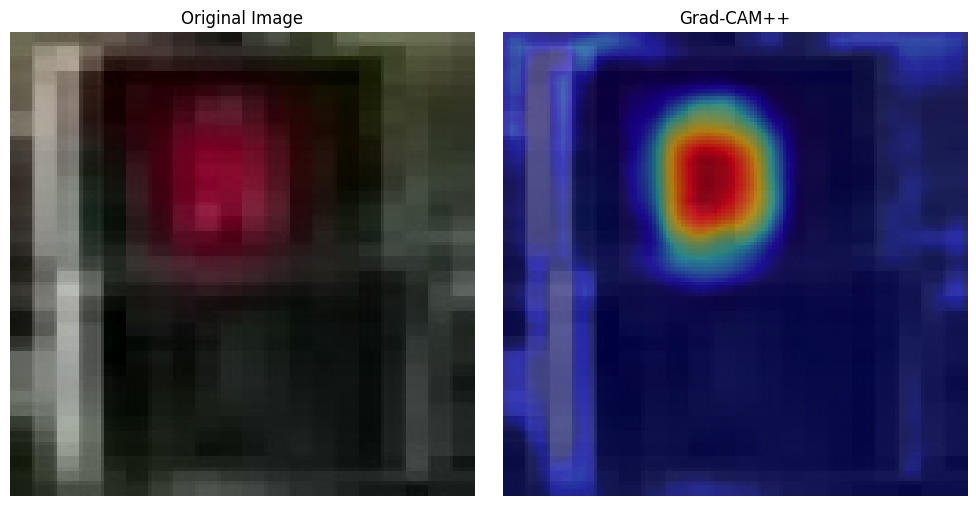

In [121]:
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt


# Crear Grad-CAM++
gradcam = GradcamPlusPlus(
    model=model,
    model_modifier=ReplaceToLinear(),
    clone=False
)


# Generar mapa de activación
cam = gradcam(
    BinaryScore(1),          # clase positiva (green)
    imagen_predecir,
    penultimate_layer="conv_3"
)


# ==========================
# Visualización
# ==========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)


# Imagen original
img = imagen_predecir[0].numpy()

# Deshacer normalización si está en [0,1]
if img.max() <= 1:
    img = img * 255

img = img.astype(np.uint8)


axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")


# Grad-CAM overlay

axes[1].imshow(img)


heatmap = np.uint8(
    cm.jet(cam[0])[..., :3] * 255
)

axes[1].imshow(
    heatmap,
    cmap="jet",
    alpha=0.5
)

axes[1].set_title("Grad-CAM++")
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [123]:
def show_gradcam_grid(
    model,
    train_ds,
    class_names,
    n_images=8,
    cols=2,
    penultimate_layer="conv_2"
):

    gradcam = GradcamPlusPlus(
        model=model,
        model_modifier=ReplaceToLinear(),
        clone=False
    )


    # ===============================
    # Obtener imágenes suficientes
    # ===============================

    images_all = []
    labels_all = []

    for images, labels in train_ds:

        images_all.append(images.numpy())
        labels_all.append(labels.numpy())

        if sum(x.shape[0] for x in images_all) >= n_images:
            break


    images_all = np.concatenate(images_all)
    labels_all = np.concatenate(labels_all)


    idxs = np.random.choice(
        len(images_all),
        n_images,
        replace=False
    )


    rows = int(np.ceil(n_images / cols))


    # Figura principal
    fig = plt.figure(
        figsize=(8 * cols, 5 * rows)
    )


    for i, idx in enumerate(idxs):

        imagen = images_all[idx]
        real_label = int(labels_all[idx])


        imagen_input = tf.expand_dims(
            imagen,
            axis=0
        )


        # Predicción
        pred_prob = model.predict(
            imagen_input,
            verbose=0
        )[0][0]

        pred_label = int(pred_prob >= 0.5)


        # GradCAM
        cam = gradcam(
            BinaryScore(pred_label),
            imagen_input,
            penultimate_layer=penultimate_layer
        )


        # Imagen visible
        img = imagen.copy()

        if img.max() <= 1:
            img *= 255

        img = img.astype(np.uint8)


        heatmap = np.uint8(
            cm.jet(cam[0])[..., :3] * 255
        )


        # ==================================
        # Crear una "celda" con dos imágenes
        # ==================================

        outer = fig.add_subplot(
            rows,
            cols,
            i + 1
        )

        outer.axis("off")

        outer.set_title(
            f"Real: {class_names[real_label]} | "
            f"Pred: {class_names[pred_label]}",
            fontsize=12
        )


        # Dentro de cada celda:
        # izquierda original
        # derecha gradcam

        inner = outer.inset_axes(
            [0, 0, 1, 1]
        )

        inner.axis("off")


        left = inner.inset_axes(
            [0, 0, 0.5, 1]
        )

        right = inner.inset_axes(
            [0.5, 0, 0.5, 1]
        )


        left.imshow(img)
        left.axis("off")
        left.set_title("Original", fontsize=8)


        right.imshow(img)
        right.imshow(
            heatmap,
            alpha=0.5
        )

        right.axis("off")
        right.set_title("Grad-CAM", fontsize=8)


    plt.tight_layout()
    plt.show()

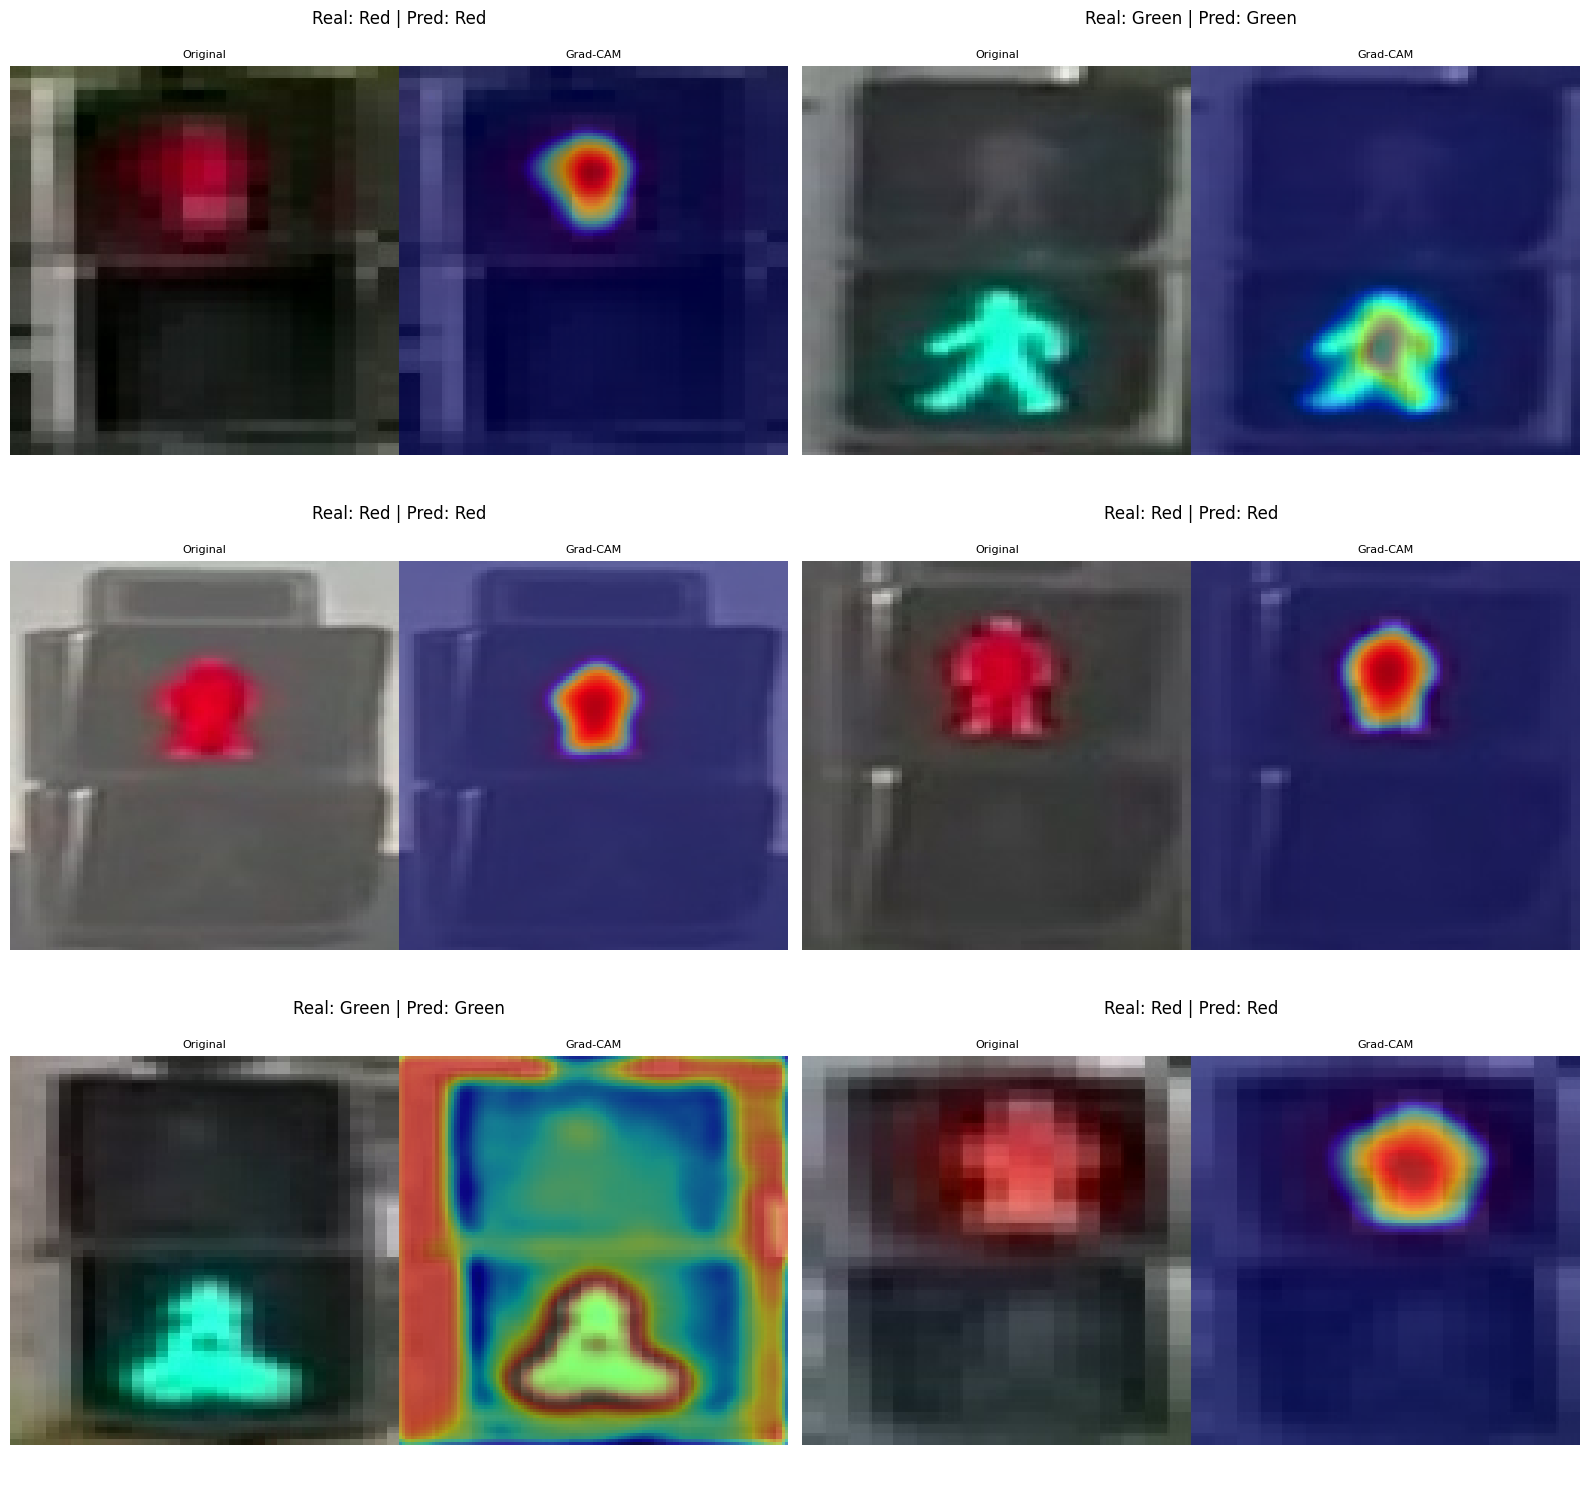

In [ ]:
show_gradcam_grid(
    model,
    train_ds,
    class_names,
    n_images=6,
    cols=2,
    penultimate_layer="conv2d_16"
)

# ERRORES

In [124]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore


def show_errors_gradcam(
    val_ds,
    model,
    class_names_list,
    penultimate_layer,
    n_images=16,
):

    gradcam = GradcamPlusPlus(
        model=model,
        model_modifier=ReplaceToLinear(),
        clone=False,
    )

    errors = []

    # ============================================================
    # Buscar errores
    # ============================================================

    for images, labels in val_ds:

        pred_probs = model.predict(images, verbose=0)

        preds = (pred_probs >= 0.5).astype(int).reshape(-1)

        labels_np = labels.numpy().astype(int).reshape(-1)

        bad_pred_inds = np.where(preds != labels_np)[0]

        for ind in bad_pred_inds:

            errors.append(
                (
                    images[ind],
                    labels_np[ind],
                    preds[ind],
                    float(pred_probs[ind][0]),
                )
            )

            if len(errors) >= n_images:
                break

        if len(errors) >= n_images:
            break

    if len(errors) == 0:
        print("No se han encontrado errores.")
        return

    # ============================================================
    # Mostrar errores + GradCAM
    # ============================================================

    fig, axes = plt.subplots(
        len(errors),
        2,
        figsize=(8, 4 * len(errors)),
    )

    if len(errors) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (image, real_label, pred_label, prob_positive) in enumerate(errors):

        image_batch = tf.expand_dims(image, axis=0)

        cam = gradcam(
            BinaryScore(1),
            image_batch,
            penultimate_layer=penultimate_layer,
        )

        img = image.numpy()

        if img.max() <= 1:
            img = img * 255

        img = img.astype(np.uint8)

        heatmap = np.uint8(
            cm.jet(cam[0])[..., :3] * 255
        )

        if pred_label == 1:
            prob_pred = prob_positive
        else:
            prob_pred = 1 - prob_positive

        if real_label == 1:
            prob_real = prob_positive
        else:
            prob_real = 1 - prob_positive

        # -----------------------------
        # Imagen original
        # -----------------------------

        axes[i, 0].imshow(img)

        axes[i, 0].set_title(
            f"Pred: {class_names_list[pred_label]} ({prob_pred:.2f})\n"
            f"Real: {class_names_list[real_label]} ({prob_real:.2f})"
        )

        axes[i, 0].axis("off")

        # -----------------------------
        # GradCAM
        # -----------------------------

        axes[i, 1].imshow(img)

        axes[i, 1].imshow(
            heatmap,
            alpha=0.5,
        )

        axes[i, 1].set_title("Grad-CAM++")

        axes[i, 1].axis("off")

    plt.tight_layout()

    plt.show()

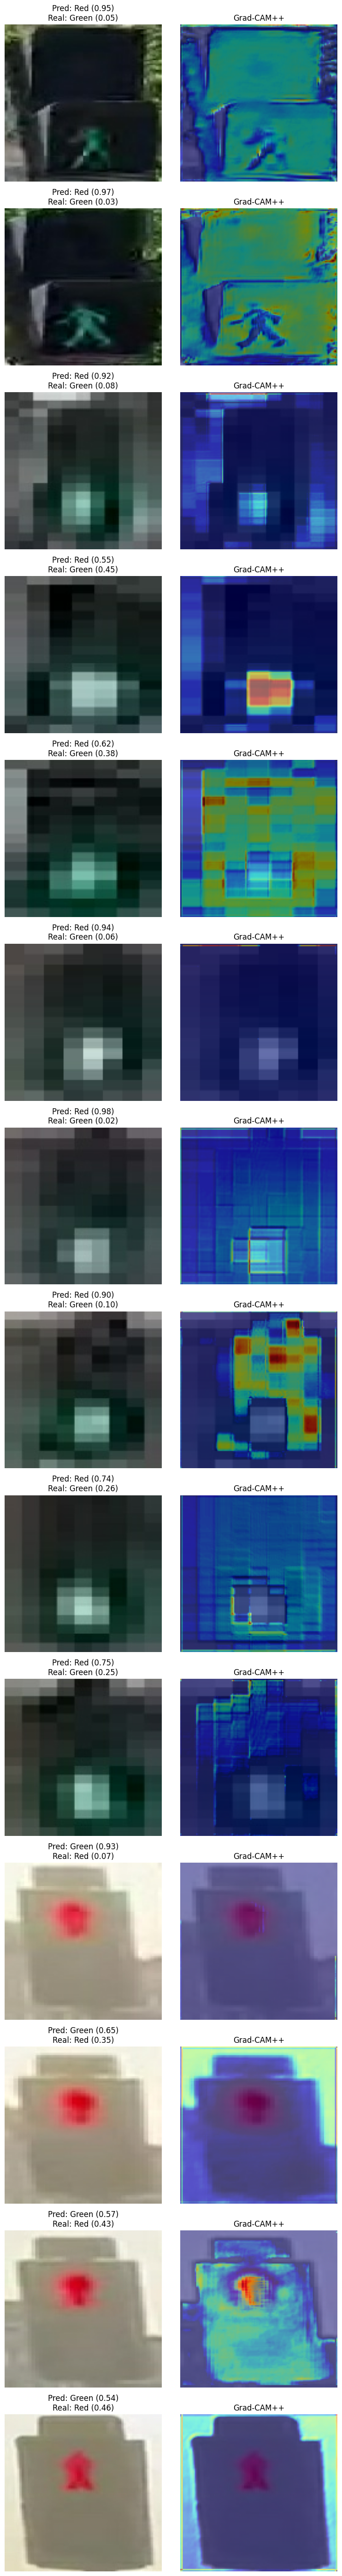

In [126]:
show_errors_gradcam(
    val_ds=val_ds,
    model=model,
    class_names_list=class_names,
    penultimate_layer="conv_2",
    n_images=20,
)

In [127]:
import numpy as np


def analyze_predictions(
    model,
    dataset,
    class_names,
    threshold=0.5,
):

    y_true = []
    y_pred = []
    y_prob = []

    false_positive = []
    false_negative = []

    for images, labels in dataset:

        probs = model.predict(images, verbose=0).reshape(-1)

        preds = (probs >= threshold).astype(int)

        labels = labels.numpy()

        y_true.extend(labels)
        y_pred.extend(preds)
        y_prob.extend(probs)

        for i in range(len(labels)):

            # FP -> Red predicho como Green
            if labels[i] == 0 and preds[i] == 1:

                false_positive.append(
                    (
                        images[i],
                        probs[i],
                    )
                )

            # FN -> Green predicho como Red
            elif labels[i] == 1 and preds[i] == 0:

                false_negative.append(
                    (
                        images[i],
                        probs[i],
                    )
                )

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    print(f"Threshold: {threshold:.2f}\n")

    print(f"TP ({class_names[1]} → {class_names[1]}): {tp}")
    print(f"TN ({class_names[0]} → {class_names[0]}): {tn}")
    print(f"FP ({class_names[0]} → {class_names[1]}): {fp}")
    print(f"FN ({class_names[1]} → {class_names[0]}): {fn}")

    return false_positive, false_negative

In [133]:
fp, fn = analyze_predictions(
    model,
    val_ds,
    class_names,
    threshold=0.99,
)

Threshold: 0.99

TP (Red → Red): 530
TN (Green → Green): 447
FP (Green → Red): 0
FN (Red → Green): 45


In [129]:
import numpy as np
import matplotlib.pyplot as plt


def plot_fp_fn_curve(model, val_ds, class_names, step=0.01):

    # ============================================
    # Obtener todas las predicciones
    # ============================================

    y_true = []
    y_prob = []

    for images, labels in val_ds:

        probs = model.predict(images, verbose=0).reshape(-1)

        y_prob.extend(probs)
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    # ============================================
    # Evaluar todos los thresholds
    # ============================================

    thresholds = np.arange(0, 1 + step, step)

    false_positives = []
    false_negatives = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))

        false_positives.append(fp)
        false_negatives.append(fn)

    # ============================================
    # Gráfico
    # ============================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds * 100,
        false_positives,
        linewidth=2,
        label=f"False Positives ({class_names[0]} → {class_names[1]})",
    )

    plt.plot(
        thresholds * 100,
        false_negatives,
        linewidth=2,
        label=f"False Negatives ({class_names[1]} → {class_names[0]})",
    )

    plt.xlabel("Threshold (%)")
    plt.ylabel("Number of errors")
    plt.title("False Positives / False Negatives vs Threshold")

    plt.grid(True)
    plt.legend()

    plt.show()

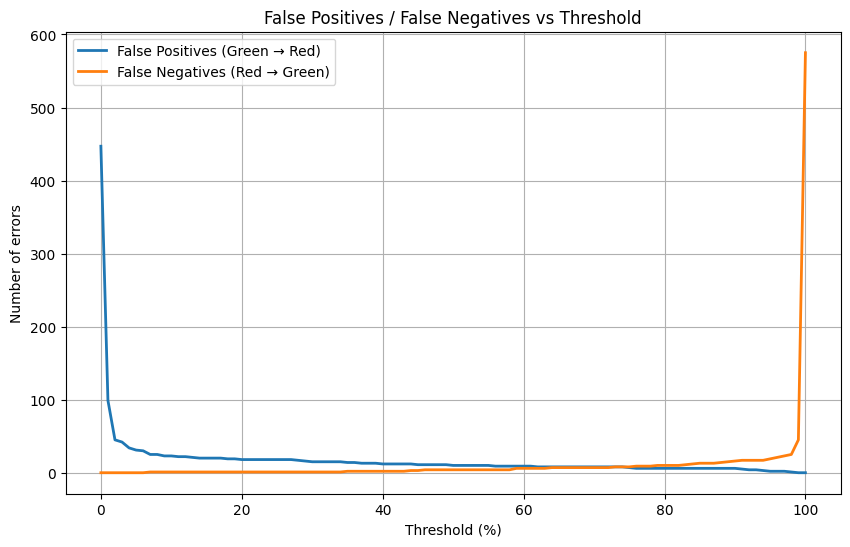

In [130]:
plot_fp_fn_curve(
    model,
    val_ds,
    class_names,
)